# 03 — EWOA Feature Selection + KNN

**Cel**: Reprodukcja artykułu — EWOA selekcja cech → KNN klasyfikacja.

Pipeline:
1. Załaduj dane CIC-MalMem-2022 (55 cech)
2. Uruchom EWOA (20 wielorybów, 30 iteracji)
3. Uruchom WOA (baseline do porównania)
4. Porównaj wyniki z artykułem (accuracy 99.987%, avg 3.97 cech)

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from sklearn.model_selection import train_test_split

from src.data.loader import load_raw_data, preprocess, make_splits
from src.algorithms import EWOA, WOA
from src.evaluation.metrics import evaluate_knn, compare_algorithms
from src.evaluation.visualization import (
    plot_convergence, plot_feature_selection,
    plot_accuracy_comparison, plot_confusion_matrix,
    plot_n_features_comparison,
    )
from src.utils.config import SEED

np.random.seed(SEED)

## 1. Ładowanie i podział danych

Dzielimy dane na trzy części:
- `train` do właściwego uczenia KNN w funkcji fitness,
- `val` do oceny jakości maski cech w EWOA/WOA,
- `test` do końcowej, uczciwej ewaluacji.

In [2]:
df = load_raw_data()
X, y = preprocess(df, mode='binary')
X_train_full, X_test, y_train_full, y_test = make_splits(X, y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.125,
    stratify=y_train_full,
    random_state=SEED,
    )

X_fit = np.vstack([X_train, X_val])
y_fit = np.concatenate([y_train, y_val])

feature_names = [c for c in df.columns if c not in ('Category', 'Class')]
print(f'Cechy ({len(feature_names)}): {feature_names[:5]} ...')
print(f'train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')

Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...
  58058 próbek | 55 cech | tryb: binary
  Rozkład klas: {'Benign': 29227, 'Malware': 28831}
  Split: train=46446, test=11612
Cechy (55): ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers'] ...
train=(40640, 55), val=(5806, 55), test=(11612, 55)


## 2. EWOA — Enhanced Whale Optimization Algorithm

In [3]:
ewoa = EWOA(n_whales=20, max_iter=30, n_neighbors=5, alpha=0.01, seed=SEED)

t0 = time.time()
ewoa_result = ewoa.optimize(X_train, y_train, X_val, y_val)
ewoa_time = time.time() - t0

print(f'\n--- EWOA ---')
print(f'Wybrane cechy ({ewoa_result["n_selected"]}): {ewoa_result["selected_features"]}')
print(f'Fitness: {ewoa_result["best_fitness"]:.6f}')
print(f'Czas: {ewoa_time:.1f} s')

if feature_names:
    selected_names = [feature_names[i] for i in ewoa_result['selected_features']]
    print(f'Nazwy cech: {selected_names}')

  [EWOA] iter   1/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter   2/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter   3/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter   4/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter   5/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


...

  [EWOA] iter  26/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter  27/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter  28/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter  29/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [EWOA] iter  30/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000

--- EWOA ---
Wybrane cechy (5): [5, 28, 29, 42, 48]
Fitness: 0.000909
Czas: 23.6 s
Nazwy cech: ['dlllist.ndlls', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_session_false_avg', 'svcscan.process_services']


## 3. WOA — bazowy Whale Optimization (porównanie)

In [4]:
woa = WOA(n_whales=20, max_iter=30, n_neighbors=5, alpha=0.01, seed=SEED)

t0 = time.time()
woa_result = woa.optimize(X_train, y_train, X_val, y_val)
woa_time = time.time() - t0

print(f'\n--- WOA ---')
print(f'Wybrane cechy ({woa_result["n_selected"]}): {woa_result["selected_features"]}')
print(f'Fitness: {woa_result["best_fitness"]:.6f}')
print(f'Czas: {woa_time:.1f} s')

  [WOA] iter   1/30 | fitness=0.003182 | features= 1/55 | ~acc=0.9970


  [WOA] iter   2/30 | fitness=0.002545 | features= 3/55 | ~acc=0.9980


  [WOA] iter   3/30 | fitness=0.002545 | features= 3/55 | ~acc=0.9980


  [WOA] iter   4/30 | fitness=0.002545 | features= 3/55 | ~acc=0.9980


  [WOA] iter   5/30 | fitness=0.001909 | features= 5/55 | ~acc=0.9990


...

  [WOA] iter  26/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [WOA] iter  27/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [WOA] iter  28/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [WOA] iter  29/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000


  [WOA] iter  30/30 | fitness=0.000909 | features= 5/55 | ~acc=1.0000

--- WOA ---
Wybrane cechy (5): [5, 10, 28, 31, 45]
Fitness: 0.000909
Czas: 15.9 s


## 4. Ewaluacja na zbiorze testowym

In [5]:
print('=== EWOA + KNN ===')
ewoa_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=ewoa_result['selected_features'],
    n_neighbors=5, algorithm_name='EWOA'
    )

print('\n=== WOA + KNN ===')
woa_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=woa_result['selected_features'],
    n_neighbors=5, algorithm_name='WOA'
    )

print('\n=== KNN baseline (55 cech) ===')
baseline_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=list(range(X_fit.shape[1])),
    n_neighbors=5, algorithm_name='KNN-all'
    )

=== EWOA + KNN ===

  EWOA + KNN (k=5)
  Wybrane cechy:  5 / 55
  Accuracy:       0.99776
  F1-macro:       0.99776
  Precision:      0.99777
  Recall:         0.99775

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5846
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612

Zapisano: C:\Users\Laptop\Desktop\Git\DL-Project\results\metrics\ewoa_results.json

=== WOA + KNN ===



  WOA + KNN (k=5)
  Wybrane cechy:  5 / 55
  Accuracy:       0.99767
  F1-macro:       0.99767
  Precision:      0.99769
  Recall:         0.99766

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5846
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612

Zapisano: C:\Users\Laptop\Desktop\Git\DL-Project\results\metrics\woa_results.json

=== KNN baseline (55 cech) ===



  KNN-all + KNN (k=5)
  Wybrane cechy:  55 / 55
  Accuracy:       0.99991
  F1-macro:       0.99991
  Precision:      0.99991
  Recall:         0.99991

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5846
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612

Zapisano: C:\Users\Laptop\Desktop\Git\DL-Project\results\metrics\knn-all_results.json


## 5. Tabela porównawcza

In [6]:
all_results = [ewoa_eval, woa_eval, baseline_eval]
comparison_df = compare_algorithms(all_results)
comparison_df


=== PORÓWNANIE ALGORYTMÓW ===
Algorytm  Cechy Accuracy F1-macro Precision  Recall
    EWOA      5  0.99776  0.99776   0.99777 0.99775
     WOA      5  0.99767  0.99767   0.99769 0.99766
 KNN-all     55  0.99991  0.99991   0.99991 0.99991

Zapisano: C:\Users\Laptop\Desktop\Git\DL-Project\results\metrics\comparison.csv


,Algorytm,Cechy,Accuracy,F1-macro,Precision,Recall
0,EWOA,5,0.99776,0.99776,0.99777,0.99775
1,WOA,5,0.99767,0.99767,0.99769,0.99766
2,KNN-all,55,0.99991,0.99991,0.99991,0.99991


## 6. Wizualizacje

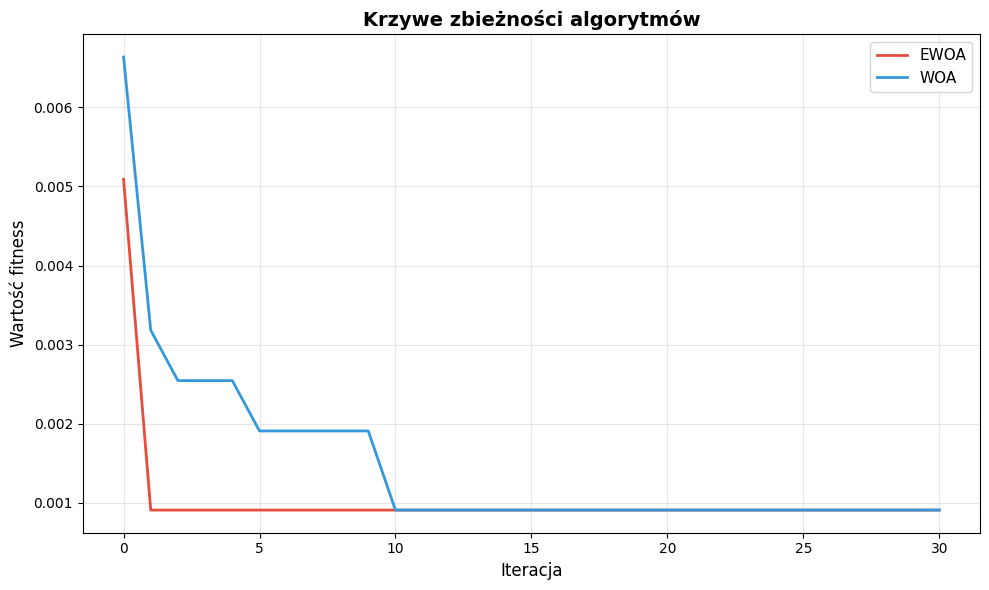

In [7]:
# Krzywe zbieżności
plot_convergence({
    'EWOA': ewoa_result['convergence'],
    'WOA': woa_result['convergence'],
})

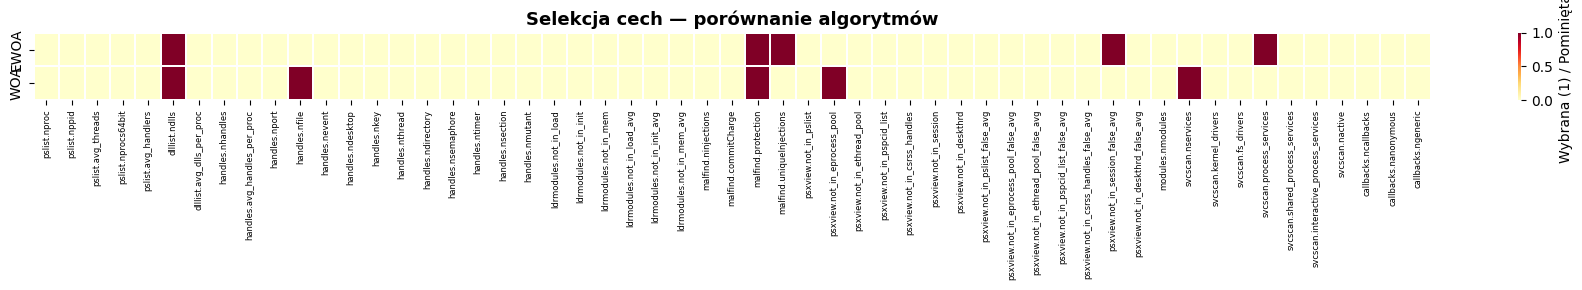

In [8]:
# Heatmapa selekcji cech
plot_feature_selection(
    {'EWOA': ewoa_result['selected_features'], 'WOA': woa_result['selected_features']},
    feature_names=feature_names,
)

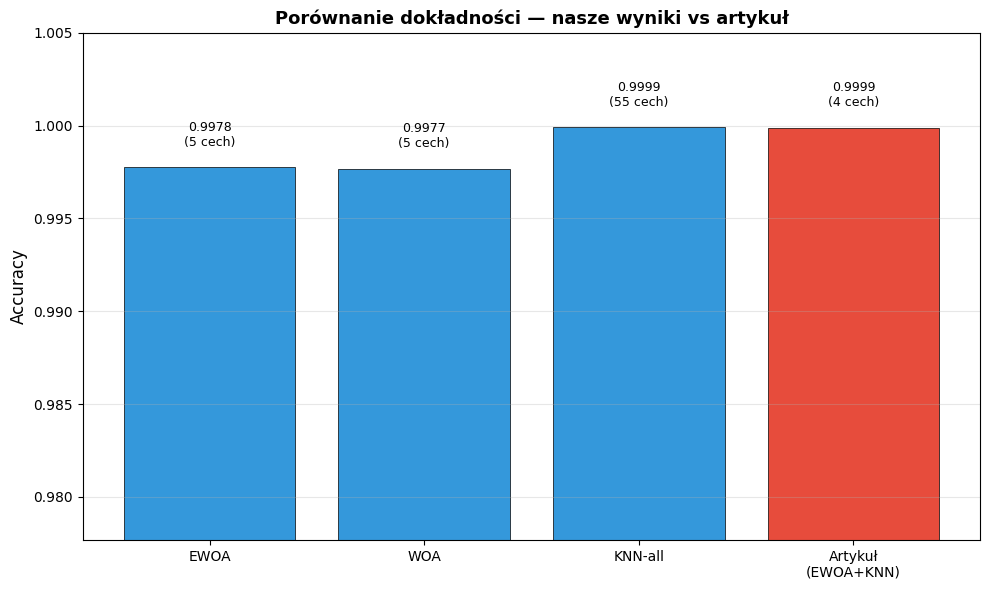

In [9]:
# Porównanie accuracy
plot_accuracy_comparison(all_results)

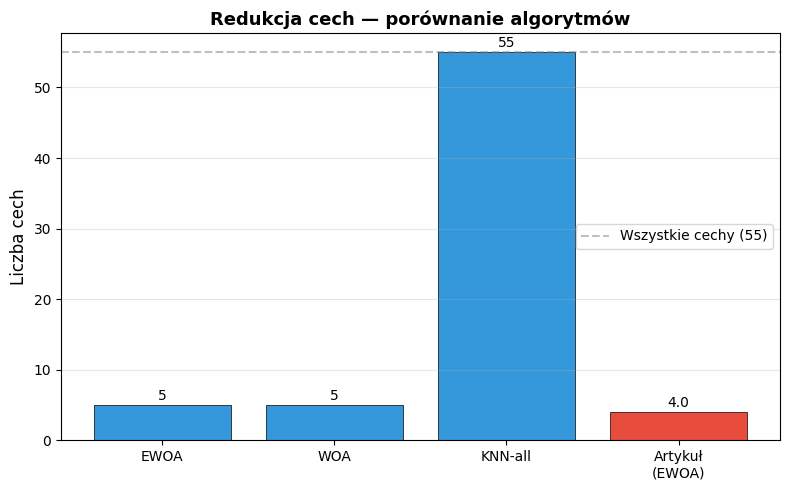

In [10]:
# Porównanie liczby cech
plot_n_features_comparison(all_results)

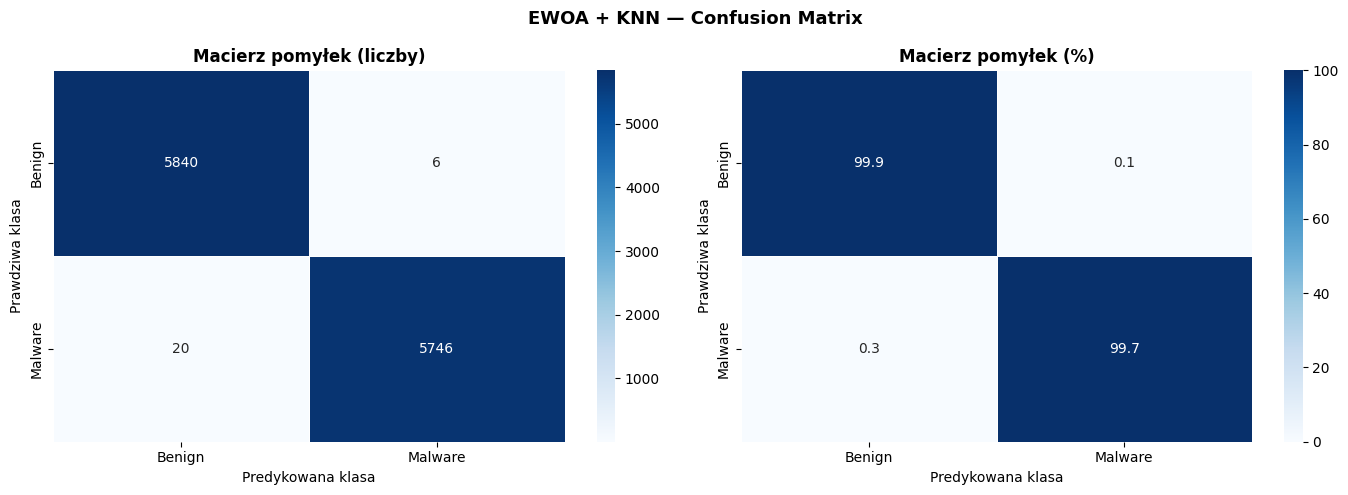

In [11]:
# Confusion matrix — EWOA
from sklearn.neighbors import KNeighborsClassifier

knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_fit[:, ewoa_result['selected_features']], y_fit)
y_pred_ewoa = knn_final.predict(X_test[:, ewoa_result['selected_features']])

plot_confusion_matrix(y_test, y_pred_ewoa, algorithm_name='EWOA', save_name='confusion_ewoa')

## 7. Porównanie z artykułem

| Metryka | Artykuł (EWOA+KNN) | Nasz wynik |
|---------|:---:|:---:|
| Accuracy | 99.987% | **patrz wyżej** |
| Avg. features | 3.97 | **patrz wyżej** |
| Avg. time | 43.19 s | **patrz wyżej** |

In [12]:
print('Porównanie z artykułem:')
print(f'  Accuracy:  nasz={ewoa_eval["accuracy"]:.5f}  vs  artykuł=0.99987')
print(f'  N cech:    nasz={ewoa_eval["n_features"]}      vs  artykuł=3.97 (avg)')
print(f'  Czas:      nasz={ewoa_time:.1f}s    vs  artykuł=43.19s')

Porównanie z artykułem:
  Accuracy:  nasz=0.99776  vs  artykuł=0.99987
  N cech:    nasz=5      vs  artykuł=3.97 (avg)
  Czas:      nasz=23.6s    vs  artykuł=43.19s
